In [22]:
# ติดตั้ง imbalanced-learn หากยังไม่มี
import subprocess
import sys

try:
    from imblearn.combine import SMOTETomek
    print("ติดตั้ง imbalanced-learn แล้ว")
except ImportError:
    print("กำลังติดตั้ง imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    print("ติดตั้งเสร็จแล้ว")



ติดตั้ง imbalanced-learn แล้ว


In [23]:
# โหลดชุดข้อมูล
# ---------------------------------
df_dirty = pd.read_csv("../data/plant_disease_dirty.csv")

print("ขนาด:", df_dirty.shape)
display(df_dirty.head())


ขนาด: (10200, 5)


,temperature,humidity,rainfall,soil_pH,disease_present
0,NaN,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,NaN,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0


In [24]:
# -----------------------------
# Basic data inspection
# -----------------------------
print(df_dirty.info())

print("\nMissing values:")
print(df_dirty.isnull().sum())

print("\nDuplicate rows:", df_dirty.duplicated().sum())

print("\nSummary statistics:")
display(df_dirty.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      9592 non-null   float64
 1   humidity         9696 non-null   float64
 2   rainfall         9484 non-null   float64
 3   soil_pH          9597 non-null   float64
 4   disease_present  10200 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 398.6 KB
None

Missing values:
temperature        608
humidity           504
rainfall           716
soil_pH            603
disease_present      0
dtype: int64

Duplicate rows: 187

Summary statistics:


,temperature,humidity,rainfall,soil_pH,disease_present
count,9592.000000,9696.000000,9484.000000,9597.000000,10200.000000
mean,25.644035,62.099535,9.885147,6.242256,0.242549
std,6.530787,25.351885,11.021827,1.458421,0.428646
min,-9.093631,-73.760795,-49.099712,-1.400969,0.000000
25%,21.768431,40.716066,2.807395,5.107728,0.000000
50%,25.269873,72.252600,6.901624,6.223098,0.000000
75%,28.989409,81.111901,13.603389,7.390160,0.000000
max,60.367985,198.102190,84.654161,14.039064,1.000000


In [25]:
# -----------------------------
# Feature description
# -----------------------------
feature_description = {
    "temperature": "อุณหภูมิ",
    "humidity": "ความชื้นสัมพัทธ์",
    "rainfall": "ปริมาณฝน",
    "soil_pH": "ค่าความเป็นกรด-ด่างของดิน",
    "disease_present": "ตัวแปรเป้าหมาย: 0 = ไม่เป็นโรค, 1 = เป็นโรค"
}

pd.DataFrame({
    "Column": feature_description.keys(),
    "Description": feature_description.values()
})

,Column,Description
0,temperature,อุณหภูมิ
1,humidity,ความชื้นสัมพัทธ์
2,rainfall,ปริมาณฝน
3,soil_pH,ค่าความเป็นกรด-ด่างของดิน
4,disease_present,"ตัวแปรเป้าหมาย: 0 = ไม่เป็นโรค, 1 = เป็นโรค"


In [26]:
# -----------------------------
# Data cleaning
# 1) ลบข้อมูลซ้ำ
# 2) ตรวจ outliers ตามช่วงที่สมเหตุสมผล
# 3) แทน outliers เป็น NaN
# 4) เติม missing ด้วย median
# -----------------------------
df_clean = df_dirty.drop_duplicates().copy()

# ตรวจช่วงค่าที่สมเหตุสมผล แล้วแทนค่าผิดช่วงเป็น NaN
df_clean.loc[(df_clean["temperature"] < 0) | (df_clean["temperature"] > 60), "temperature"] = np.nan
df_clean.loc[(df_clean["humidity"] < 0) | (df_clean["humidity"] > 100), "humidity"] = np.nan
df_clean.loc[(df_clean["rainfall"] < 0), "rainfall"] = np.nan
df_clean.loc[(df_clean["soil_pH"] < 0) | (df_clean["soil_pH"] > 14), "soil_pH"] = np.nan

# เติมค่าที่หายไปด้วย median
for col in ["temperature", "humidity", "rainfall", "soil_pH"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Shape after cleaning:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())
print("\nDuplicate rows after cleaning:", df_clean.duplicated().sum())

Shape after cleaning: (10013, 5)

Missing values after cleaning:
temperature        0
humidity           0
rainfall           0
soil_pH            0
disease_present    0
dtype: int64

Duplicate rows after cleaning: 0


disease_present
0    7597
1    2416
Name: count, dtype: int64


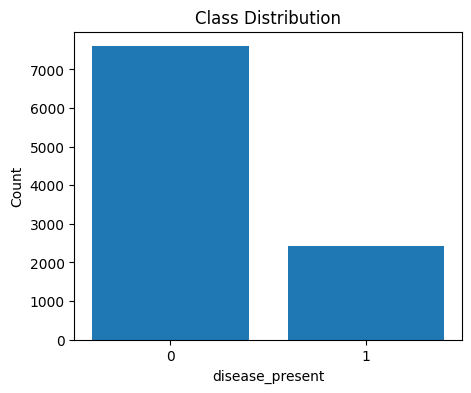

In [27]:
# -----------------------------
# Check class distribution
# -----------------------------
class_counts = df_clean["disease_present"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(5,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("disease_present")
plt.ylabel("Count")
plt.show()

In [28]:
# -----------------------------
# Split features and target
# -----------------------------
X = df_clean[["temperature", "humidity", "rainfall", "soil_pH"]]
y = df_clean["disease_present"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())

X shape: (10013, 4)
y shape: (10013,)


,temperature,humidity,rainfall,soil_pH
0,25.295507,33.215053,0.572758,4.975875
1,24.308678,36.945005,42.522346,8.165266
2,28.238443,34.026189,16.095303,6.316734
3,25.295507,41.104180,20.311015,6.164949
4,23.829233,51.971785,11.851323,8.482468


0    1
1    0
2    1
3    0
4    0
Name: disease_present, dtype: int64

In [29]:
# -----------------------------
# Train-test split
# stratify เพื่อคงสัดส่วนคลาส
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train: (8010, 4)
X_test : (2003, 4)
y_train distribution:
 disease_present
0    6077
1    1933
Name: count, dtype: int64
y_test distribution:
 disease_present
0    1520
1     483
Name: count, dtype: int64


In [30]:
# -----------------------------
# Baseline model: Random Forest
# ใช้เพื่อเทียบก่อนทำ ensemble
# -----------------------------
rf_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix (Baseline):")
print(confusion_matrix(y_test, y_pred_rf))

Baseline Accuracy: 0.8282576135796306

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1520
           1       0.69      0.53      0.60       483

    accuracy                           0.83      2003
   macro avg       0.77      0.73      0.74      2003
weighted avg       0.82      0.83      0.82      2003


Confusion Matrix (Baseline):
[[1402  118]
 [ 226  257]]


In [31]:
# Balance training data with SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Apply SMOTETomek to balance classes
print("Before balancing:")
print("y_train distribution:\n", y_train.value_counts())

smt = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smt.fit_resample(X_train, y_train)

print("\nAfter balancing with SMOTETomek:")
print("y_train_balanced distribution:\n", pd.Series(y_train_balanced).value_counts())
print("Original shape:", X_train.shape)
print("Balanced shape:", X_train_balanced.shape)


Before balancing:
y_train distribution:
 disease_present
0    6077
1    1933
Name: count, dtype: int64

After balancing with SMOTETomek:
y_train_balanced distribution:
 disease_present
0    5822
1    5822
Name: count, dtype: int64
Original shape: (8010, 4)
Balanced shape: (11644, 4)


In [32]:
# -----------------------------
# Ensemble model
# ประกอบด้วย 3 โมเดล:
# 1) Random Forest
# 2) SVM
# 3) XGBoost
# รวมผลด้วย Soft Voting
# -----------------------------

# คำนวณค่าน้ำหนักสำหรับ XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

# SVM
svm = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale",
    probability=True,
    random_state=42,
    class_weight="balanced"
)

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

# Pipeline รวม preprocessing + ensemble
ensemble_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", VotingClassifier(
        estimators=[
            ("rf", rf),
            ("svm", svm),
            ("xgb", xgb)
        ],
        voting="soft",
        weights=[1, 1.5, 1.2]  # Weight SVM higher as it handles imbalance better
    ))
])

# เทรนโมเดลด้วยข้อมูลที่ balance แล้ว
ensemble_model.fit(X_train_balanced, y_train_balanced)

scale_pos_weight: 3.1438178996378685


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [33]:
# -----------------------------
# Evaluate final Model 1
# -----------------------------
y_pred = ensemble_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Final Model 1 Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Final Model 1 Accuracy: 0.7868197703444832

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1520
           1       0.55      0.69      0.61       483

    accuracy                           0.79      2003
   macro avg       0.72      0.76      0.73      2003
weighted avg       0.81      0.79      0.79      2003


Confusion Matrix:
[[1241  279]
 [ 148  335]]



Threshold Optimization:
Default threshold (0.5) - Accuracy: 0.7868
Optimal threshold (0.54) - Accuracy: 0.8038

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1520
           1       0.58      0.67      0.62       483

    accuracy                           0.80      2003
   macro avg       0.74      0.76      0.75      2003
weighted avg       0.82      0.80      0.81      2003



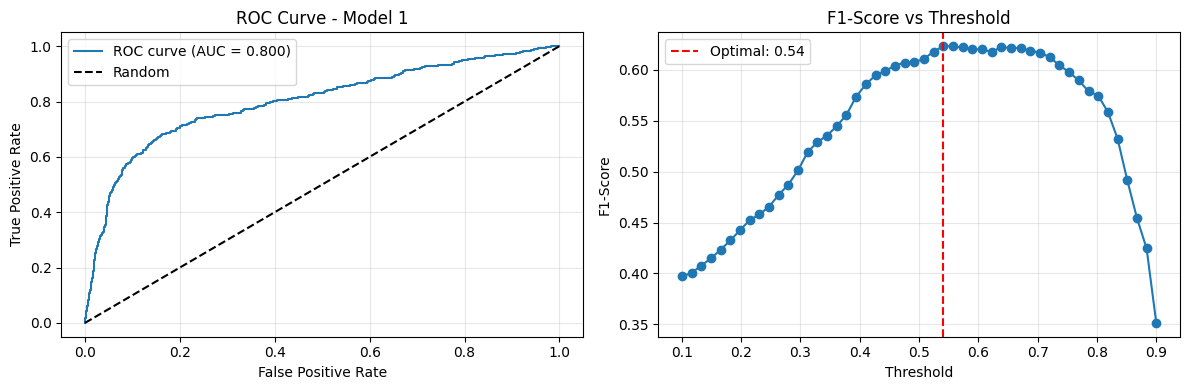


Optimal threshold for deployment: 0.541


In [34]:
# Optimize threshold for better recall (detect diseases better)
from sklearn.metrics import roc_curve, auc

# Get probability predictions
y_pred_proba = ensemble_model.predict_proba(X_test)[:, 1]

# Find optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Use threshold that maximizes F1-score
from sklearn.metrics import f1_score
f1_scores = []
for threshold in np.linspace(0.1, 0.9, 50):
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)
    f1_scores.append(f1)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = np.linspace(0.1, 0.9, 50)[optimal_idx]

print("\nThreshold Optimization:")
print(f"Default threshold (0.5) - Accuracy: {accuracy_score(y_test, y_pred):.4f}")

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print(f"Optimal threshold ({optimal_threshold:.2f}) - Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_optimal))

# Plot ROC curve and F1-score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC curve
axes[0].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Model 1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-score vs threshold
axes[1].plot(np.linspace(0.1, 0.9, 50), f1_scores, 'o-')
axes[1].axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for deployment: {optimal_threshold:.3f}")


<Figure size 500x400 with 0 Axes>

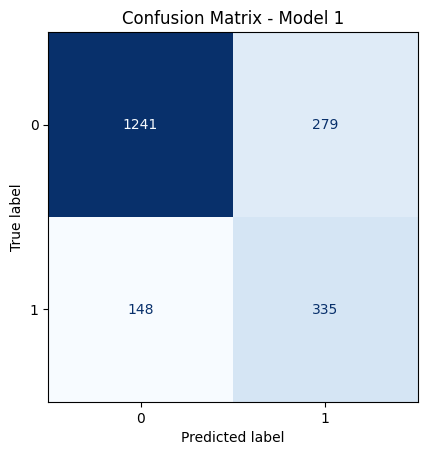

In [35]:
# -----------------------------
# Plot confusion matrix
# -----------------------------
plt.figure(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Model 1")
plt.show()

,feature,importance_mean,importance_std
3,soil_pH,0.085771,0.006712
1,humidity,0.070994,0.006011
2,rainfall,0.067599,0.007825
0,temperature,0.030654,0.006107


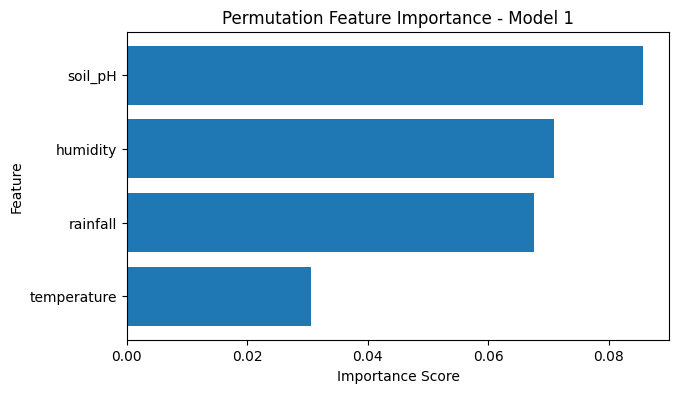

In [36]:
# -----------------------------
# Permutation importance
# ใช้ดูว่าฟีเจอร์ไหนมีผลต่อโมเดลมาก
# -----------------------------
result = permutation_importance(
    ensemble_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)

display(importance_df)

plt.figure(figsize=(7,4))
plt.barh(importance_df["feature"], importance_df["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Model 1")
plt.show()

In [37]:
# -----------------------------
# Single prediction example
# ใช้ตัวอย่างสำหรับหน้าเว็บ
# -----------------------------
sample = pd.DataFrame([{
    "temperature": 28.5,
    "humidity": 75.0,
    "rainfall": 12.0,
    "soil_pH": 6.4
}])

pred = ensemble_model.predict(sample)[0]

print("Predicted disease_present:", pred)
print("ตีความ:", "Disease Present" if pred == 1 else "No Disease")

Predicted disease_present: 1
ตีความ: Disease Present


In [38]:
# -----------------------------
# Save final model
# ใช้ไฟล์นี้ในหน้าเว็บ Model 1 Test
# -----------------------------
joblib.dump(ensemble_model, "model1_final.pkl")
print("Saved: model1_final.pkl")

Saved: model1_final.pkl


In [39]:
# -----------------------------
# Save test sample file
# ใช้สำหรับหน้าเว็บเลือกแถวตัวอย่าง
# -----------------------------
test_sample_df = X_test.copy()
test_sample_df["actual_label"] = y_test.values
test_sample_df = test_sample_df.reset_index(drop=True)

test_sample_df.to_csv("model1_test_samples.csv", index=False)
print("Saved: model1_test_samples.csv")

display(test_sample_df.head())

Saved: model1_test_samples.csv


,temperature,humidity,rainfall,soil_pH,actual_label
0,33.631133,62.323460,30.423093,7.393153,0
1,54.526216,92.115531,17.721275,13.537243,1
2,25.295507,41.071453,0.432608,5.733389,0
3,29.212569,82.588789,3.182107,7.777542,0
4,18.747961,26.140733,3.795631,4.350164,0


In [40]:
# -----------------------------
# Summary dictionary
# ใช้เก็บผลลัพธ์หลักไว้เขียนรายงาน
# -----------------------------
summary = {
    "dataset_type": "Structured / Tabular",
    "features": ["temperature", "humidity", "rainfall", "soil_pH"],
    "target": "disease_present",
    "data_issues": [
        "missing values",
        "duplicate rows",
        "outliers"
    ],
    "preprocessing_steps": [
        "remove duplicates",
        "replace out-of-range values with NaN",
        "fill missing values using median",
        "train/test split",
        "class balancing with class_weight"
    ],
    "model_type": "Ensemble Learning",
    "base_models": ["Random Forest", "SVM", "XGBoost"],
    "ensemble_method": "Soft Voting",
    "accuracy": acc
}

summary

{'dataset_type': 'Structured / Tabular',
 'features': ['temperature', 'humidity', 'rainfall', 'soil_pH'],
 'target': 'disease_present',
 'data_issues': ['missing values', 'duplicate rows', 'outliers'],
 'preprocessing_steps': ['remove duplicates',
  'replace out-of-range values with NaN',
  'fill missing values using median',
  'train/test split',
  'class balancing with class_weight'],
 'model_type': 'Ensemble Learning',
 'base_models': ['Random Forest', 'SVM', 'XGBoost'],
 'ensemble_method': 'Soft Voting',
 'accuracy': 0.7868197703444832}